In [21]:
import numpy as np
import matplotlib.pyplot as plt
import time
import cv2

Text(0.5, 1.0, 'Recon Time Domain')

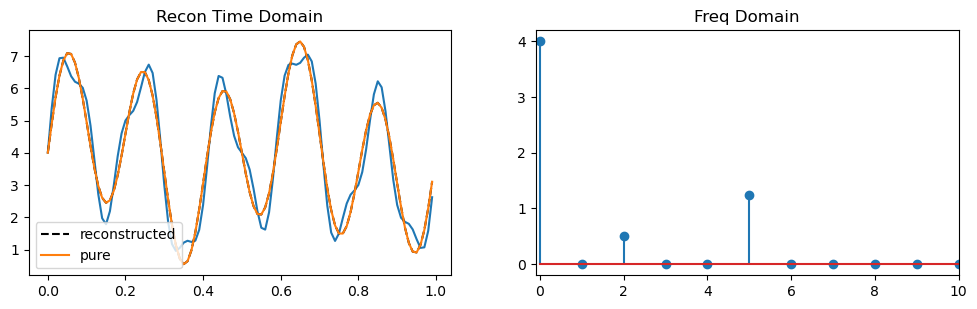

In [98]:
N = 100
fs = 100

t = np.arange(N) * 1 / fs
n = np.arange(N)
wave = np.sin(2 * np.pi * 2 * t) + 2.5 * np.sin(2 * np.pi * 5 * t) + 0.7 * np.sin(2 * np.pi * 12 * t) + 4
fCoeffs = np.fft.fft(wave) / N
hz = np.arange(N) * fs / N

plt.figure(figsize=(12, 7))
plt.subplot(221)
plt.plot(t, wave)
plt.title("Time Domain")

plt.subplot(222)
plt.stem(hz, np.abs(fCoeffs))
plt.title("Freq Domain")
plt.xlim(-0.1, 10)

# inverse
recon = np.zeros(N, dtype="complex")
for i in range(N // 2):
    mult = 1 if i == 0 else 2

    if hz[i] <= 8 or hz[i] >= 20:
        cws = fCoeffs[i] * np.exp(1j * 2 * np.pi * i * n / N) * mult
        recon += cws

plt.subplot(221)
plt.plot(t, np.real(recon), "k--", label="reconstructed")
plt.plot(t, np.sin(2 * np.pi * 2 * t) + 2.5 * np.sin(2 * np.pi * 5 * t) + 4, label="pure")
plt.legend()
plt.title("Recon Time Domain")

In [94]:
hz[int(39 * N / fs)]

np.float64(38.0)

In [ ]:
recon2 = np.dot(fCoeffs, np.exp(1j * 2 * np.pi * n/N))
fCoeffs.shape, np.exp(1j * 2 * np.pi * n/N).shape

((100,), (100,))